In [1]:
import pandas 
from collections import defaultdict
import numpy as np
import demes
import moments 
import dpluspy
import demesdraw
import scipy
import matplotlib
import matplotlib.pylab as plt
import matplotlib.ticker


In [2]:
graph_file = "full_struc_model_round_0_init.yaml"


In [3]:
def plot_on_ax(ax, data, model, stats, labels, colors, title):
    means = data["means"]
    v = data["varcovs"]
    bins = data["bins"]
    x = (bins[1:] + bins[:-1]) / 2
    pop_ids = data["pop_ids"]
    statistics = model.names()[0]

    for j, stat in enumerate(stats):
        k = statistics.index(stat)
        label = labels[j]
        err = np.array([v[l][k, k] ** 0.5 * 1.96 for l in range(len(x))])
        y = np.array([means[j][k] for j in range(len(x))])
        ax.fill_between(x, y - err, y + err, alpha=0.3, color=colors[j],
                        edgecolor='none')
        ax.plot(x, y, linestyle="dashed", color=colors[j])
        y = [model[l][k] for l in range(len(x))]
        ax.plot(x, y, color=colors[j], label=label)
    # ax setup
    # logfmt = matplotlib.ticker.LogFormatterExponent(base=10.0, labelOnlyBase=True)
    # ax.yaxis.set_major_formatter(logfmt)
    ax.set_xscale("log")
    ax.set_title(title, fontsize=7,)
    #ax.set_xlabel("$r$")
    #ax.set_xlabel("$D^+$")


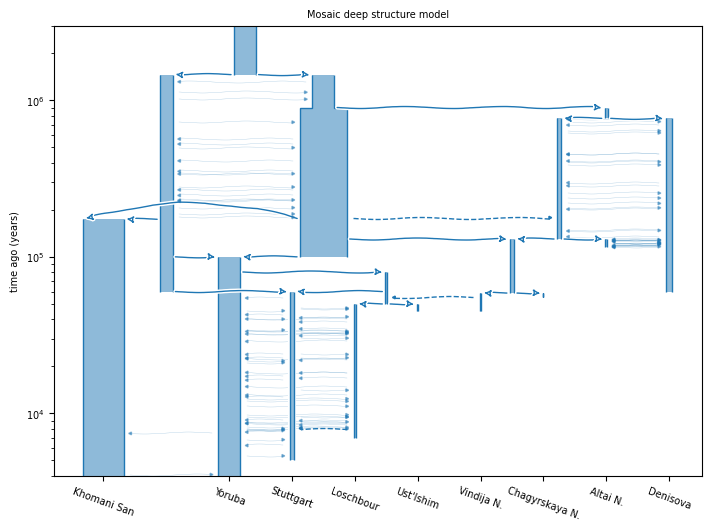

In [8]:
matplotlib.rc("font", size=7)
matplotlib.rc("xtick", labelsize=7)
matplotlib.rc("ytick", labelsize=7)
matplotlib.rc("axes", labelsize=7)
matplotlib.rc("axes", titlesize=7)
matplotlib.rc("legend", fontsize=7)

mosaic = """
A
"""
fig, axs = plt.subplot_mosaic(mosaic, figsize=(7, 5.2), layout="constrained",
    width_ratios=[1])


graph = demes.load("plot_model.yaml")
samples = [
    "KhomaniSan1", 
    "Yoruba1", 
    "Stuttgart",
    "UstIshim",
    "Loschbour",
    "Vindija", 
    "Chagyrskaya", 
    "Altai", 
    "Denisova"
]
labels = [
    "Khomani San", 
    "Yoruba", 
    "Stuttgart",
    "Ust'Ishim",
    "Loschbour",
    "Vindija N.", 
    "Chagyrskaya N.", 
    "Altai N.", 
    "Denisova"
]

positions = {
    "KhomaniSan1": -40000,
    "Yoruba1": 40000,
    "Stuttgart": 80000,
    "Loschbour": 120000,
    "UstIshim": 160000,
    "Vindija": 2e5,
    "Chagyrskaya": 2.4e5,
    "Altai": 2.8e5,
    "Denisova": 3.2e5,

    "Anc": 5e4,
    "Stem1": 1e5,
    "Stem2": 0,
    "OOA": 1.4e5,
    "ND": 2.8e5,
    "NW": 2.2e5,
    "N": 2.5e5,
}
axs["A"].set_title(r"Mosaic deep structure model")
demesdraw.tubes(
    graph,
    ax=axs["A"],
    max_time=3e6,
    log_time=True,
    labels=None,
    colours="tab:blue",
    positions=positions
)
axs["A"].spines["top"].set_visible(True)
axs["A"].spines["right"].set_visible(True)
axs["A"].spines["bottom"].set_visible(True)
xlocs = [positions[sample] for sample in samples]
axs["A"].tick_params(axis="x", reset=True, bottom=True, top=False)
axs["A"].set_xticks(xlocs, labels, rotation=-20)
axs["A"].set_ylim(4e3, )

plt.savefig("figures/full_model_figure.svg", transparent=True)